In [1]:
import numpy as np
import matplotlib.pyplot as plt
from random import choices
from scipy.stats import norm
from IPython.display import clear_output

In [2]:
plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')

Duplicate key in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 40 ('figure.dpi: 150')


In [ ]:
def probability_istar_given_psi_and_iorb(istar_deg, given_psi_deg, given_iorb_deg):
    istar_rad = np.deg2rad(istar_deg)
    given_psi_rad = np.deg2rad(given_psi_deg)
    given_iorb_rad = np.deg2rad(given_iorb_deg)

    return (1/np.pi) * ((np.sin(istar_rad))/(np.sqrt(np.sin(given_psi_rad)**2 * np.sin(given_iorb_rad)**2 - (np.cos(given_psi_rad) * np.cos(given_iorb_rad) - np.cos(istar_rad))**2)))

def probability_psi_given_kappa(psi_deg, given_kappa):
    psi_rad = np.deg2rad(psi_deg)
    return given_kappa / (2 * np.sinh(given_kappa)) * np.exp(given_kappa * np.cos(psi_rad)) * np.sin(psi_rad)

def average_psi(given_kappa):
    return np.rad2deg(np.sqrt(np.pi/2) * given_kappa**(-1/2))

def probability_istar_given_iorb_kappa(kappa, observed_istar_deg, observed_sigma_istar_deg, observed_iorb_deg, given_kappa):

    normal_dist = norm(loc=observed_istar_deg, scale=observed_sigma_istar_deg)
    P_observed_istar = normal_dist.pdf(observed_istar_deg)

    d_psi = 1
    min_psi = abs(observed_istar_deg - observed_iorb_deg)
    psi = np.arange(min_psi, 180 + d_psi, d_psi)
    istar = np.arange(0, 90 + d_psi, d_psi) ########################

    P_istar_kappa_k = []

    for given_istar_deg in istar:

        P_istar_kappa_psi_prime_i = []

        for psi_ii, psi_i in enumerate(psi):

            istar_greater_than = abs(observed_iorb_deg - psi_i)
            istar_less_than = 180 - abs(180 - observed_iorb_deg - psi_i)
            istar_valid = np.arange(istar_greater_than + d_psi, istar_less_than, d_psi)
            # P_istar_i_valid = probability_istar_given_psi_and_iorb(istar_deg=istar_valid, given_psi_deg=psi_i, given_iorb_deg=observed_iorb_deg)

            if given_istar_deg <= istar_greater_than:
                P_istar_kappa_psi_prime_i.append(0)
            elif given_istar_deg >= istar_less_than:
                P_istar_kappa_psi_prime_i.append(0)
            else:
                P_istar_i = probability_istar_given_psi_and_iorb(istar_deg=given_istar_deg, given_psi_deg=psi_i, given_iorb_deg=observed_iorb_deg)
                P_psi_i = probability_psi_given_kappa(psi_deg=psi_i, given_kappa=given_kappa)

                P_istar_kappa_psi_prime_i.append(P_istar_i * P_psi_i)

        # P_istar_kappa_psi_prime_i = np.array(P_istar_kappa_psi_prime_i) / sum(P_istar_kappa_psi_prime_i)
        P_istar_kappa_psi_prime = sum(P_istar_kappa_psi_prime_i)

        P_istar_kappa_k.append(P_istar_kappa_psi_prime * P_observed_istar)

    # P_istar_kappa_k = np.array(P_istar_kappa_k) / sum(P_istar_kappa_k)
    P_istar_kappa = sum(P_istar_kappa_k)

    return P_istar_kappa
    

def probability_kappa_prior(given_kappa):
    return (1 + given_kappa**2)**(-3/4)

def probability_kappa_given_istar_iorb(kappa, observed_istar_deg, observed_sigma_istar_deg, given_iorb_deg):

    P_kappa_prior_full = probability_kappa_prior(given_kappa=kappa)

    P_istar_kappa = []

    # for given_kappa in random_kappas:
    for given_kappa_i, given_kappa in enumerate(kappa):

        clear_output(wait=True)
        print(np.round(given_kappa_i/len(kappa) * 100,1), '%')

        P_istar_kappa_i = probability_istar_given_iorb_kappa(kappa=kappa, observed_istar_deg=observed_istar_deg, observed_sigma_istar_deg=observed_sigma_istar_deg, observed_iorb_deg=given_iorb_deg, given_kappa=given_kappa)
        P_kappa_prior_i = probability_kappa_prior(given_kappa=given_kappa)
        # finite_mask = np.isfinite(np.array(P_kappa_prior_full))
        # P_kappa_prior_i = P_kappa_prior_i / (sum(P_kappa_prior_full[finite_mask]) * np.diff(kappa)[0])

        if np.isfinite(P_istar_kappa_i) == False:
            P_istar_kappa_i = 0

        P_istar_kappa.append(P_istar_kappa_i * P_kappa_prior_i) 

    return P_istar_kappa
    







/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_83064/2176941718.py:13: RuntimeWarning: divide by zero encountered in power
  return np.rad2deg(np.sqrt(np.pi/2) * given_kappa**(-1/2))
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_83064/2176941718.py:6: RuntimeWarning: invalid value encountered in sqrt
  return (1/np.pi) * ((np.sin(istar_rad))/(np.sqrt(np.sin(given_psi_rad)**2 * np.sin(given_iorb_rad)**2 - (np.cos(given_psi_rad) * np.cos(given_iorb_rad) - np.cos(istar_rad))**2)))
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_83064/2176941718.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return given_kappa / (2 * np.sinh(given_kappa)) * np.exp(given_kappa * np.cos(psi_rad)) * np.sin(psi_rad)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_83064/2176941718.py:6: RuntimeWarning: divide by zero encountered in divide
  return (1/np.pi) * ((np.sin(istar_rad))/(np.sqrt(np.sin(given_psi_rad)**2 * np.sin(given_iorb_rad)**2 - (

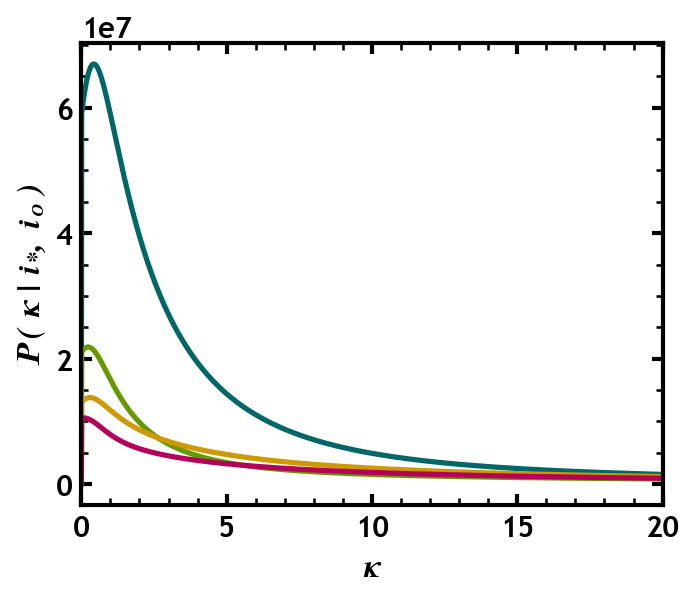

In [142]:
for observed_iorb_deg in [10, 30, 60, 90]:

    # observed_iorb_deg = 45
    observed_istar_deg = 45
    observed_istar_err = 4

    normal_dist = norm(loc=observed_istar_deg, scale=observed_istar_err)
    P_observed_istar = normal_dist.pdf(observed_istar_deg)

    kappas = np.arange(0, 20, 0.01)
    P_kappa_normalize = (1 + kappas**2)**(-3/4) # probability_kappa_prior(given_kappa=kappas)
    # P_kappa_normalize = P_kappa_normalize / (sum(P_kappa_normalize) * 0.01)

    # plt.plot(kappas, P_kappa_normalize)
    # plt.xlim(0, 20)
    # plt.show()

    # d_psi = 1
    # min_psi = abs(observed_istar_deg - observed_iorb_deg)
    # psi = np.arange(min_psi, 180 + d_psi, d_psi)
    # psi = np.arange(0, 180 + d_psi, d_psi)

    assumed_psi_deg = average_psi(given_kappa=kappas)

    P_kappa_istar = []


    for kappa_i, kappa in enumerate(kappas):

        P_istar_kappa = []


        # istar_greater_than = abs(observed_iorb_deg - assumed_psi_deg[kappa_i])
        # istar_less_than = 180 - abs(180 - observed_iorb_deg - assumed_psi_deg[kappa_i])
        # istar = np.arange(istar_greater_than + d_psi, istar_less_than, d_psi)
        
        # assumed_psi_deg = assumed_psi_deg[assumed_psi_deg >= min_psi] and assumed_psi_deg < 180]
        # assumed_psi_deg = assumed_psi_deg[assumed_psi_deg < 180]

        d_psi = 1
        istar = np.arange(0, 90 + d_psi, d_psi)

        for given_istar_deg in istar:

            min_psi = abs(given_istar_deg - observed_iorb_deg)
            psi = np.arange(min_psi, 180 + d_psi, d_psi)

            P_istar = probability_istar_given_psi_and_iorb(istar_deg=given_istar_deg, given_psi_deg=psi, given_iorb_deg=observed_iorb_deg)
            P_psi = probability_psi_given_kappa(psi_deg=psi, given_kappa=kappa)

            # print(len(P_istar))
            # print(len(P_psi))

            psi_valid = psi[np.isfinite(P_istar) == True]
            P_psi = P_psi[np.isfinite(P_istar) == True]
            P_istar = P_istar[np.isfinite(P_istar) == True]

            P_istar_i = P_istar / (sum(P_istar) * d_psi)
            P_psi_i = P_psi / (sum(P_psi) * d_psi)

            P_istar_kappa_psi_prime = sum(P_istar * P_psi)

            P_istar_kappa.append(P_istar_kappa_psi_prime * P_observed_istar)

        P_istar_kappa = np.array(P_istar_kappa)[np.isfinite(np.array(P_istar_kappa)) == True]

        # print(P_istar_i)
        # print(P_psi_i)

        P_kappa_prior_i = (1 + kappa**2)**(-3/4) # probability_kappa_prior(given_kappa=kappa)
        P_kappa_prior_i = P_kappa_prior_i / (sum(P_kappa_normalize) * np.diff(kappas)[0])

        P_kappa_istar.append(sum(P_istar_kappa) * P_kappa_prior_i)

    plt.plot(kappas, P_kappa_istar)

plt.xlabel(r'$\kappa$', fontsize=16)
plt.ylabel(r'$P~(~\kappa~|~i_{*},~i_{o}~)$', fontsize=16)
plt.xlim(0, 20)
plt.show()

In [ ]:
# test_iorb = 70
# test_istar = 80
# test_istar_err = 4

# d_kappa = 0.1
# kappa = np.arange(d_kappa, 360 + d_kappa, d_kappa)

# # d_kappa = 0.05
# # # kappa0 = [0]
# # # kappa1 = np.arange(1, 10, d_kappa) / 1000
# # kappa2 = np.arange(1, 10, d_kappa) / 100
# # kappa3 = np.arange(1, 10, d_kappa) / 10
# # kappa4 = np.arange(1, 10, d_kappa)
# # kappa5 = np.arange(1, 10, d_kappa) * 10
# # kappa6 = np.arange(1, 5-d_kappa, d_kappa) * 100
# # # kappa7 = np.arange(1, 10, d_kappa) * 1000
# # kappa = np.concatenate((kappa2, kappa3, kappa4, kappa5, kappa6))
# # kappa = np.array(kappa)


In [39]:
P_kappa = probability_kappa_given_istar_iorb(kappa, observed_istar_deg=test_istar, observed_sigma_istar_deg=test_istar_err, given_iorb_deg=test_iorb)
P_kappa = P_kappa / (np.nansum(P_kappa) * d_kappa)

100.0 %


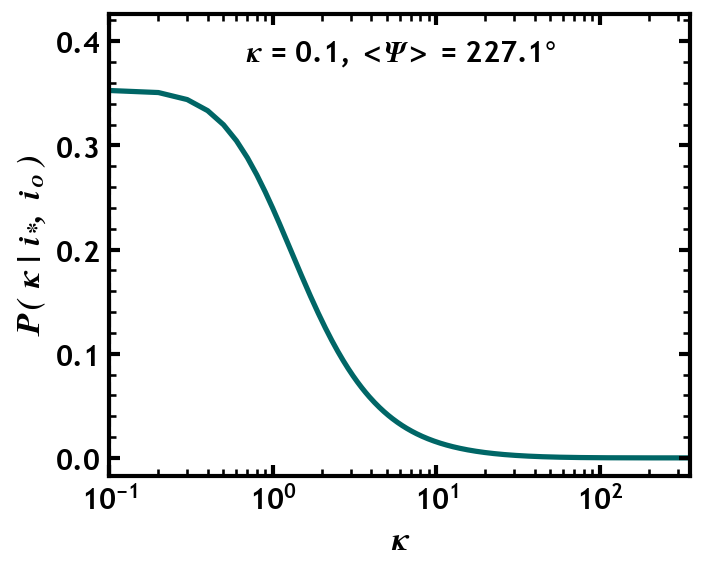

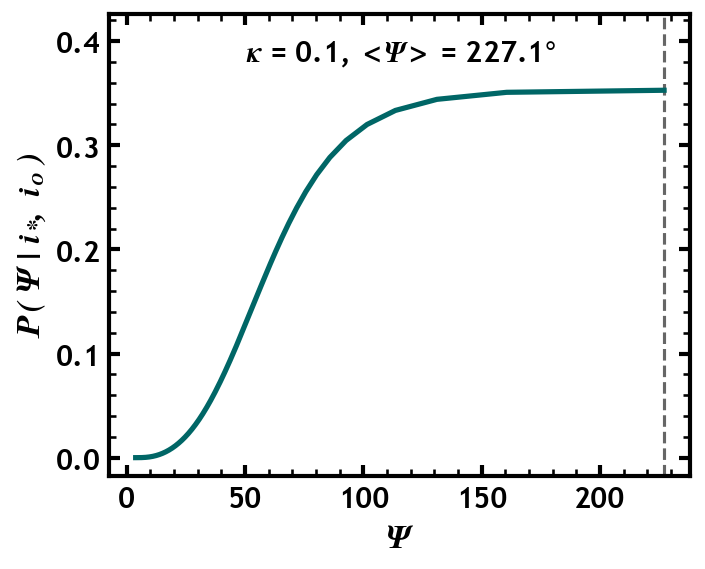

In [44]:


MAP_kappa = kappa[P_kappa == np.nanmax(P_kappa)]
psi_avg_max = average_psi(given_kappa=MAP_kappa)


plot_both = [False, True]

for plot in plot_both:

    plot_psi = plot
    if plot_psi != True:
        plot_kappa = True
    else:
        plot_kappa = False

    psi_avg = average_psi(given_kappa=kappa)
    # psi_avg[np.isinf(psi_avg) == True] = 0
    # print(psi_avg)

    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(111)
    ax.minorticks_on()
    if plot_kappa == True:
        ax.set_xlabel(r'$\kappa$', fontsize=16)
        ax.set_ylabel(r'$P~(~\kappa~|~i_{*},~i_{o}~)$', fontsize=16)
        ax.plot(kappa, P_kappa, alpha=1, zorder=-150)
        xmin, xmax = min(kappa), max(kappa)
    if plot_psi == True:
        ax.set_xlabel(r'$\Psi$', fontsize=16)
        ax.set_ylabel(r'$P~(~\Psi~|~i_{*},~i_{o}~)$', fontsize=16)
        ax.plot(psi_avg, P_kappa, alpha=1, zorder=-150)
        xmin, xmax = 0, 180

    ymin, ymax = ax.get_ylim()[0], 1.15 * ax.get_ylim()[1]

    label_text = r"$\kappa$ = " + "{:.1f}".format(MAP_kappa[0]) + ', ' + r"$<\Psi>$ = " + "{:.1f}".format(psi_avg_max[0]) + r"$\degree$"
    ax.text(0.5, 0.88, label_text, horizontalalignment='center', verticalalignment='bottom', transform=ax.transAxes)

    if plot_kappa == True:
        ax.plot([MAP_kappa[0], MAP_kappa[0]], [ymin, ymax], '--', color='#000000', lw=1.5, alpha=0.6, zorder=-200)
        ax.set_xscale('log')
        ax.set_xlim(xmin, xmax)
    if plot_psi == True:
        ax.plot([psi_avg_max[0], psi_avg_max[0]], [ymin, ymax], '--', color='#000000', lw=1.5, alpha=0.6, zorder=-200)
        # xticks = [0, 30, 60, 90, 120, 150, 180]
        # ax.set_xticks(xticks)
        # ax.set_xticklabels(xticks)
        # ax.set_xlim(xmin, xmax)

    # ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


    plt.show()

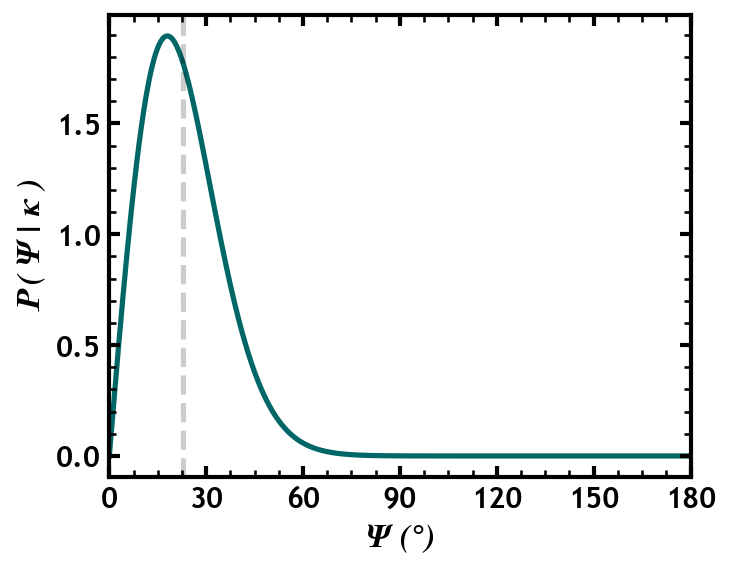

In [ ]:

kappa = 10.
d_psi = 0.1
psi = np.arange(0, 180 + d_psi, d_psi)

avg_psi = np.degrees(np.sqrt(np.pi/2) * kappa**(-1/2))

P_psi = probability_psi_given_kappa(psi_deg=psi, given_kappa=kappa)

# ---------------------------------------

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111)
ax.minorticks_on()
ax.set_xlabel(r'$\Psi$ $(\degree)$', fontsize=16)
ax.set_ylabel(r'$P~(~\Psi~|~\kappa~)$', fontsize=16)

ax.plot(psi, P_psi, alpha=1, zorder=-150)

xmin, xmax = min(psi), max(psi)
ymin, ymax = ax.get_ylim()

ax.plot([avg_psi, avg_psi], [ymin, ymax], '--', color='#000000', alpha=0.2, zorder=-100)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

xticks = [0, 30, 60, 90, 120, 150, 180]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)

plt.show()

In [ ]:
# test_psi = 120
# test_iorb = 90

# istar_greater_than = abs(test_iorb - test_psi)
# istar_less_than = 180 - abs(180 - test_iorb - test_psi)
# d_istar = 1
# istar = np.arange(istar_greater_than + d_istar, istar_less_than - d_istar, d_istar)
# print('istar_greater_than: ', istar_greater_than)
# print('istar_less_than: ', istar_less_than)

# P_istar = probability_istar_given_psi_and_iorb(istar_deg=istar, given_psi_deg=test_psi, given_iorb_deg=test_iorb)

# avg_istar = sum([np.radians(i) * P_istar[ii] for ii, i in enumerate(istar)])

# # ---------------------------------------

# fig = plt.figure(figsize=(5, 4))
# ax = fig.add_subplot(111)
# ax.minorticks_on()
# ax.set_xlabel(r'$i_{*}$ $(\degree)$', fontsize=16)
# ax.set_ylabel(r'$P~(~i_{*}~|~\Psi,~i_{o}~)$', fontsize=16)

# ax.plot(istar, P_istar, alpha=1, zorder=-150)

# xmin, xmax = 0, 180
# ymin, ymax = ax.get_ylim()

# ax.plot([avg_istar, avg_istar], [ymin, ymax], '--', color='#000000', alpha=0.2, zorder=-100)

# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# xticks = [0, 30, 60, 90, 120, 150, 180]
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticks)

# plt.show()